# Лекция 1. Знакомство с обучением с подкреплением

**Цели лекции**

1. Выделить основные отличительные черты Reinforcement Learning.
2. Понимать области применения Reinforcement Learning.
3. Разобраться, что отличает Reinforcement Learning от других областей машинного обучения.

Сегодня мы, ничего не зная про физику, научим программу раскачать машинку на горке и провести агента по замёрзшему озеру. Кода будет меньше, чем кажется: первый рабочий алгоритм RL умещается в двадцать строк.

**План и хронометраж (одна пара, 90 минут)**

| | Раздел | Минут |
|---|---|---|
| 1 | Как устроен курс | 5 |
| 2 | Что такое Reinforcement Learning | 5 |
| 3 | Три вида машинного обучения | 8 |
| 4 | Где применяется RL | 6 |
| 5 | Ключевые понятия: состояние, действие, награда, политика, эпизод | 9 |
| 6–7 | Примеры сред и упражнение «определите сами» | 5 |
| 8–9 | Живые демо: CartPole и тележка на горке | 9 |
| 10 | Марковское свойство и MDP | 7 |
| 11 | Награда — это формулировка задачи | 4 |
| 12 | Исследование и использование | 4 |
| 13 | Как оценить политику: метод Монте-Карло | 5 |
| 14 | Первый алгоритм: метод Cross-Entropy | 18 |
| 15 | Карта курса и итоги | 5 |
| | **Итого** | **90** |

Пометки в заголовках: **📖 дома** — материал для самостоятельного чтения, на лекции можно пропустить; **⏱ если есть время** — резерв.

## 1. Как устроен курс

* **16 недель**, одно занятие в неделю: лекция + семинар. Каждая неделя — папка `NN-topic-name/` в репозитории с тремя ноутбуками: `lecture/`, `seminar/`, `homework/`.
* **Домашние задания** почти каждую неделю, в `.ipynb`. Часть проверок — через `assert`, так что можно проверить себя до сдачи.
* **Оценка** (черновик, обсуждаем сегодня): 60% домашние задания, 30% итоговый проект, 10% активность на семинарах.
* **Итоговый проект**: своя реализация RL-агента или мини-исследование на среде по выбору. Темы выбираем на неделе 14, защита на неделе 16.
* **Инструменты**: Python 3.10+, [Gymnasium](https://gymnasium.farama.org/) (среды), [PyTorch](https://pytorch.org/) (нейросети), Jupyter.
  Библиотеки [Stable-Baselines3](https://stable-baselines3.readthedocs.io/) и [CleanRL](https://github.com/vwxyzjn/cleanrl) читаем как справочник, но алгоритмы в домашках пишем сами.
* **Что нужно уметь на входе**: линейная алгебра, теория вероятностей, градиентный спуск, Python с numpy. Нейросети и PyTorch — желательно, но необходимый минимум разберём на мини-семинаре `../seminar/pytorch_intro.ipynb`.

Установка окружения:

```bash
python -m venv .venv && source .venv/bin/activate
pip install -r requirements.txt
```

## 2. Что такое Reinforcement Learning

Начнём с картинки, которую все понимают без определений: дрессировщик и собака.

<img src="../../assets/ref/agent_env_dog.png" width="420">

Собака **наблюдает** (жест, голос), **действует** (садится, лает, убегает), а дрессировщик выдаёт **награду** (лакомство есть или нет). Никто не объясняет собаке, *как* правильно, есть только последствия. Через десяток повторений действие, за которым идёт лакомство, случается чаще. Это и есть обучение с подкреплением.

Та же схема в общем виде:

<img src="../../assets/ref/agent_env_brain.png" width="420">

* **Агент** — тот, кто принимает решения (мозг, программа). Единственное, что мы обучаем.
* **Среда** — всё остальное: физический мир, игра, биржа, другой игрок.
* На каждом шаге $t$ агент видит **состояние** $S_t$ (или наблюдение), выбирает **действие** $A_t$, среда отвечает **наградой** $R_t$ и новым состоянием $S_{t+1}$.

**Цель агента** — максимизировать суммарную награду

$$
G = \sum_{t=0}^{\infty} \gamma^t R_t, \qquad \gamma \in [0, 1].
$$

Вопрос залу: как научить собаку команде, если объяснить словами вы ничего не можете? Ответ — единственный доступный канал связи: поощрять то, что похоже на нужное поведение. Дальше вся лекция про то, как это записать формально и запрограммировать.

**Reinforcement Learning (RL)** — раздел машинного обучения о том, как агент, взаимодействуя со средой, учится выбирать действия так, чтобы суммарная награда была как можно больше.

<small>Иллюстрации в этом и следующем разделах — из лекции 1 курса [imm-rl-lab](https://github.com/imm-rl-lab/reinforcement_learning_course) (А. Плаксин).</small>

### Откуда слово «подкрепление»

Термин пришёл из психологии. **Закон эффекта** Торндайка (1911): действия с приятными последствиями в той же ситуации повторяются чаще. **Подкрепление** (reinforcement) у Скиннера (1938): всё, что увеличивает частоту поведения. Математику добавила теория оптимального управления: **Беллман** (1957). **Саттон и Барто** в 1980-х соединили обе линии в то, что теперь называется RL.

![origins](../../assets/rl_origins.png)

> **Факт.** В 1997 году нейробиологи обнаружили, что дофаминовые нейроны в мозге реагируют не на саму награду, а на **разницу между ожидаемой и полученной** наградой — то есть вычисляют в точности ту величину, которую RL-алгоритмы называют ошибкой временной разности. Теория, придуманная для машин, оказалась моделью того, как учится живой мозг.
>
> **Факт.** В 2025 году Ричард Саттон и Эндрю Барто получили **премию Тьюринга** (аналог Нобелевской в информатике) как раз за создание reinforcement learning. Область, с которой мы начинаем, — молодая: её основателям вручили главную премию буквально на днях.

## 3. Три вида машинного обучения

Где RL живёт на карте машинного обучения? Три большие группы задач отличаются не алгоритмами, а тем, **какие данные доступны** и **откуда берётся сигнал для обучения**.

![paradigms](../../assets/ml_paradigms.png)

**Обучение с учителем (supervised).** Дана таблица примеров с правильными ответами — пары $(x_i, y_i)$; модель ищет $f(x) \approx y$, ошибка на каждом примере известна сразу.

* спам-фильтр: $x$ — текст письма, $y$ — «спам / не спам» (разметку сделали люди кнопкой «в спам»);
* диагностика по снимку: $x$ — рентген, $y$ — диагноз врача;
* прогноз спроса: $x$ — день недели, погода, цена; $y$ — сколько продали (ответ известен из истории).

**Обучение без учителя (unsupervised).** Ответов нет, есть только объекты $x_i$; задача — найти структуру.

* кластеризация клиентов: на какие группы делятся покупатели (сколько групп — заранее не знает никто);
* поиск аномалий: транзакция не похожа на остальные — возможно, мошенничество;
* эмбеддинги и снижение размерности: сжать 10 000 признаков в 50, сохранив «похожесть».

**Обучение с подкреплением (reinforcement).** Ни таблицы с ответами, ни фиксированного набора данных. Есть **среда**, в которой агент действует, и **награда** — число в ответ на действия.

* игра: агент видит экран, нажимает кнопки, в конце партии узнаёт, выиграл или проиграл;
* робот: подаёт токи на моторы, награда — прошёл ли метр и не упал ли;
* охлаждение дата-центра: меняет уставки кондиционеров, награда — минус потраченная энергия при соблюдении температуры.

Вопрос залу: сколько размеченных примеров нужно, чтобы обучить робота ходить «с учителем»? Столько, сколько правильных траекторий для каждой ситуации вы готовы записать руками, — и это главная причина, почему такой подход не работает.

| | Supervised | Unsupervised | Reinforcement |
|---|---|---|---|
| Что дано | пары $(x, y)$ | только $x$ | среда для взаимодействия |
| Обратная связь | правильный ответ сразу | нет | награда, часто с задержкой |
| Откуда данные | собраны заранее | собраны заранее | порождает сам агент |
| Что оптимизируем | ошибку предсказания | структуру в данных | суммарную награду |
| Решения влияют на данные | нет | нет | **да** |

**Четыре отличительные черты RL**

1. **Нет правильного ответа, есть оценка.** Учитель не говорит «здесь нужно было повернуть налево», есть только число.
2. **Отложенная награда.** В шахматах результат приходит через 40 ходов после решающей ошибки: какое из 40 действий виновато? Это задача **credit assignment**.
3. **Данные порождает сам агент.** Плохая политика видит только плохие состояния; данные не независимы и меняются по ходу обучения.
4. **Нужно исследовать.** Чтобы найти лучшее поведение, надо пробовать новое, а новое в среднем невыгодно (раздел 12).

Границы, конечно, размыты: RL умеет пользоваться и разметкой (imitation learning — учимся повторять за экспертом), и предобученными представлениями. А в разделе 14 мы увидим алгоритм, который на каждом шаге превращает задачу RL в обычную задачу обучения с учителем — на данных, которые агент собрал себе сам.

### Разминка: какой это тип обучения?

Два вопроса на каждый пункт: *есть ли правильные ответы* и *влияют ли решения модели на будущие данные*.

1. По истории поездок предсказать время в пути до университета.
2. Научить манипулятор перекладывать детали; известен только процент успешно переложенных.
3. Разбить 50 000 отзывов на тематические группы, чтобы понять, на что жалуются.
4. Подобрать порядок новостей в ленте так, чтобы пользователь читал больше в течение месяца.

<details>
<summary>Ответы</summary>

1. **Supervised**: для каждой прошлой поездки известно фактическое время.
2. **Reinforcement**: правильная траектория неизвестна, есть только результат попытки.
3. **Unsupervised**: разметки тем нет.
4. **Reinforcement**: правильного порядка не существует, награда отложена на месяц, и лента сама определяет, какие данные мы увидим завтра.

</details>

## 4. Где применяется RL

Общий рецепт: как только у задачи есть **среда** (или её симулятор) и **числовая цель**, поведение можно не программировать, а выучить.

![timeline](../../assets/rl_timeline.png)

### Игры

| Год | Система | Что произошло | Посмотреть |
|---|---|---|---|
| 1992 | **TD-Gammon** | Нейросеть + TD-обучение играет в нарды на уровне чемпионов мира. | [статья](https://dl.acm.org/doi/10.1145/203330.203343) |
| 2015 | **DQN** | Одна сеть учится играть в 49 игр Atari по пикселям и счёту. | [видео Breakout](https://www.youtube.com/watch?v=TmPfTpjtdgg), [Nature](https://www.nature.com/articles/nature14236) |
| 2016 | **AlphaGo** | Победа над Ли Седолем в го. | [фильм](https://www.youtube.com/watch?v=WXuK6gekU1Y) |
| 2017 | **AlphaZero** | Шахматы, сёги и го с нуля, только игрой с самим собой. | [блог](https://deepmind.google/discover/blog/alphazero-shedding-new-light-on-chess-shogi-and-go/) |
| 2019 | **OpenAI Five**, **AlphaStar** | Dota 2 и StarCraft II на уровне профессионалов. | [OpenAI Five](https://openai.com/index/openai-five/), [AlphaStar](https://deepmind.google/discover/blog/alphastar-mastering-the-real-time-strategy-game-starcraft-ii/) |
| 2019 | **Hide and Seek** | Агенты в прятках сами изобретают использование инструментов. | [блог с гифками](https://openai.com/index/emergent-tool-use/) |

Почему игры: есть симулятор, чёткая награда и можно сыграть миллионы партий. OpenAI Five за время обучения наиграла эквивалент десятков тысяч лет Dota 2.

> **Факт.** В 1992 году TD-Gammon научился играть в нарды сам с собой — и стал делать дебютные ходы, которые люди считали ошибочными. Через несколько лет теорию дебютов в нардах переписали под машину.
>
> **Факт.** Во второй партии с Ли Седолем AlphaGo сыграл 37-й ход, который комментаторы сочли ошибкой: вероятность такого хода у человека оценивали как один к десяти тысячам. Партию AlphaGo выиграл, а ход вошёл в учебники го.

### Робототехника

> **Факт.** В 2023 году дрон, обученный с подкреплением ([Swift](https://www.nature.com/articles/s41586-023-06419-4)), обыграл чемпионов мира по гонкам дронов на их же трассе.

[Роботы-футболисты DeepMind](https://sites.google.com/view/op3-soccer), [ходьба четвероногих ANYmal](https://arxiv.org/abs/1901.08652), [Boston Dynamics Spot](https://bostondynamics.com/blog/starting-on-the-right-foot-with-reinforcement-learning/), [кубик Рубика одной рукой](https://openai.com/index/solving-rubiks-cube/). Общая схема: учим в симуляторе, переносим на железо (sim-to-real).

### Управление инфраструктурой

* [Охлаждение дата-центров Google](https://deepmind.google/discover/blog/deepmind-ai-reduces-google-data-centre-cooling-bill-by-40/): минус 40% энергии на охлаждение. Состояние — сотни датчиков, действия — уставки оборудования, награда — энергия при соблюдении температурных ограничений.
* [Управление плазмой в токамаке](https://www.nature.com/articles/s41586-021-04301-9): RL-контроллер держит форму плазмы через токи в 19 магнитных катушках.
* Светофоры, балансировка сетей, [размещение блоков на чипе](https://deepmind.google/discover/blog/how-alphachip-transformed-computer-chip-design/).

### Финансы: торговля на бирже

Исполнение крупных ордеров (как разбить заявку, чтобы не сдвинуть цену), маркет-мейкинг, управление портфелем. Честная оговорка: рынок нестационарен и очень шумный, поэтому это гораздо труднее, чем Atari. Обзор: [Deep RL for trading](https://arxiv.org/abs/1911.10107), учебная библиотека [FinRL](https://github.com/AI4Finance-Foundation/FinRL).

### Роевое поведение дронов

Несколько агентов учатся одновременно держать строй, облетать препятствия, вместе искать цель. Каждый дрон видит только соседей, награда общая — это **multi-agent RL** (неделя 15). [Полёт роя сквозь лес](https://arxiv.org/abs/2202.03308), среды [PettingZoo](https://pettingzoo.farama.org/) и [gym-pybullet-drones](https://github.com/utiasDSL/gym-pybullet-drones).

### Рекомендации и языковые модели

Что показать пользователю, чтобы он остался надолго, а не только кликнул сейчас. Ответы модели на 1.3 млрд параметров, дообученной с помощью RL на человеческих предпочтениях, люди предпочитали ответам модели на 175 млрд параметров без такого дообучения. **RLHF** ([InstructGPT](https://arxiv.org/abs/2203.02155)): ChatGPT стал полезным собеседником благодаря RL на человеческих предпочтениях; **рассуждающие модели** ([DeepSeek-R1](https://arxiv.org/abs/2501.12948)) обучены RL на проверяемых наградах.

**Интерактивные демо**: [ReinforceJS](https://cs.stanford.edu/people/karpathy/reinforcejs/) (GridWorld в браузере), [каталог сред Gymnasium](https://gymnasium.farama.org/environments/classic_control/), [Hugging Face Deep RL Course](https://huggingface.co/learn/deep-rl-course/unit0/introduction).

## 5. Ключевые понятия

Словарь, которым будем пользоваться весь курс.

<img src="../../assets/ref/agent_env_brain.png" width="420">

* **Состояние** $S_t$ — описание ситуации в среде: клетка в лабиринте, четыре числа в CartPole, кадр игры. Состояния должно хватать для принятия решения (раздел 10).
* **Наблюдение** $O_t$ — то, что реально видит агент. Если видно не всё (покер, туман войны), состояние и наблюдение различаются; пока считаем, что совпадают.
* **Действие** $A_t$ — чем агент влияет на среду. Бывают **дискретные** (4 направления, кнопки джойстика) и **непрерывные** (моменты на 17 суставах гуманоида).
* **Награда** $R_t$ — число от среды после действия. Единственный сигнал обучения: агент не знает, какое действие было «правильным», он знает только, сколько ему заплатили.
* **Политика** $\pi$ — правило выбора действия по состоянию, то, что мы обучаем. Детерминированная $a = \pi(s)$ выдаёт одно действие, **стохастическая** $\pi(a \mid s)$ — распределение над действиями. Стохастичность не для красоты: пока агент учится, он обязан пробовать разное (раздел 12).

### Эпизод и терминальное состояние

**Терминальное состояние** — состояние, из которого взаимодействие не продолжается: шест упал, агент дошёл до цели, партия закончилась. Дальше наград нет, и по определению ценность терминального состояния равна нулю — поэтому в коде мы всегда отдельно обрабатываем последний шаг.

**Эпизод** — одна траектория от начала до терминального состояния: партия, заезд, попытка робота. Задачи бывают **эпизодические** (игра, лабиринт, посадка корабля — есть естественный конец и `env.reset()`) и **непрерывные** (управление котельной, торговый агент — конца нет).

В Gymnasium шаг возвращает два разных флага, и путать их нельзя:

* `terminated=True` — среда действительно пришла в терминальное состояние (цель достигнута, агент погиб), будущих наград нет;
* `truncated=True` — эпизод оборвали снаружи по лимиту шагов (в CartPole это 500), среда могла бы продолжаться.

**Траектория** $\tau = (S_0, A_0, R_0, S_1, A_1, R_1, \ldots)$ — то, что получилось за эпизод. Её качество измеряется **суммарной дисконтированной наградой** (return):

$$
G_t = R_t + \gamma R_{t+1} + \gamma^2 R_{t+2} + \ldots = \sum_{k \ge 0} \gamma^k R_{t+k}, \qquad \gamma \in [0, 1].
$$

Коэффициент $\gamma$ говорит, насколько агента волнует далёкое будущее: награда через $k$ шагов весит $\gamma^k$, горизонт планирования — примерно $1/(1-\gamma)$ шагов. При $\gamma = 0$ агент близорук, при $\gamma \to 1$ готов терпеть ради выигрыша в конце. Для коротких эпизодов можно брать $\gamma = 1$.

**Цель RL**: найти политику $\pi$, максимизирующую ожидаемый return $\mathbb{E}_\pi[G_0]$. Всё остальное в курсе — способы это сделать.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
from matplotlib import animation                  # анимации в разделах 9 и 14
from IPython.display import HTML, display

ks = np.arange(0, 200)
for gamma in [0.5, 0.9, 0.99]:
    plt.plot(ks, gamma ** ks, label=f"γ = {gamma}: горизонт ≈ {1/(1-gamma):.0f} шагов")
plt.xlabel("k (через сколько шагов придёт награда)")
plt.ylabel("вес награды γ^k")
plt.title("Дисконтирование: насколько агенту важно будущее")
plt.legend()
plt.show()

## 6. Примеры сред

Для каждой задачи отвечаем на четыре вопроса: **что агент видит**, **что может делать**, **за что ему платят**, **когда эпизод заканчивается**.

### Лабиринт

<img src="../../assets/ref/maze.png" width="260">

* **Состояния**: белые клетки; агент всегда знает, где стоит.
* **Действия**: ↑, →, ↓, ←; шаг в стену оставляет на месте.
* **Награда**: −1 на каждом шаге, 0 в цели — чем быстрее дошёл, тем меньше штрафа.
* **Эпизод**: от старта до цели (или до лимита шагов).

Агенту никто не говорит «иди направо»: что путь хороший, он узнаёт только по сумме штрафов в конце.

### Frozen Lake

<img src="../../assets/ref/frozen_lake.png" width="260">

Тот же лабиринт, но лёд **скользкий**: выбранное действие выполняется не всегда. Награда 1 за достижение цели и 0 иначе, проруби — терминальные состояния. Это наша основная учебная среда на сегодня.

### Atari

<img src="../../assets/ref/atari.png" width="380">

* **Состояния**: кадры с экрана (пиксели), обычно 4 подряд, чтобы было видно направление движения.
* **Действия**: до 18 положений джойстика. **Награда**: изменение игрового счёта.
* **Эпизод**: до конца игры. Одна и та же архитектура учится играть в десятки разных игр.

### CartPole, Mountain Car и гуманоид

<img src="../../assets/ref/cartpole.png" width="240">

**CartPole**: состояние — четыре числа (позиция и скорость тележки, угол и угловая скорость шеста), действия — толкнуть влево или вправо, награда +1 за каждый шаг, пока шест не упал. Терминальное состояние — падение шеста или выезд за границы.

**Mountain Car**: машинка в низине между горками, мотор слабый — «в лоб» на правый холм не заехать, надо откатиться назад и раскачаться. Состояние — позиция и скорость (непрерывные), действия — газ влево / ничего / газ вправо, награда −1 за каждый шаг, терминальное состояние — флажок на вершине. Отличная иллюстрация того, что **жадность к мгновенной награде вредна**: чтобы получить меньше штрафа, надо сначала поехать *от* цели.

<img src="../../assets/ref/humanoid.png" width="240">

**Гуманоид (MuJoCo)**: 17 суставов, непрерывные действия — моменты на каждом; награда за скорость вперёд минус затраты энергии; эпизод обрывается при падении. Разница с лабиринтом только в размерности — постановка та же.

## 7. Определите сами

Разберём вслух две задачи. Что здесь состояние, действие, награда, когда эпизод заканчивается и где в среде случайность?

**Шахматы против соперника.**

<details>
<summary>Разбор</summary>

Состояние — позиция на доске (плюс права на рокировку и т. п.); действие — легальный ход; награда — 0 на каждом ходу и ±1 в конце партии; эпизод — партия; случайность среды — это ходы соперника: с точки зрения нашего агента соперник является частью среды.

</details>

**Охлаждение дата-центра.**

<details>
<summary>Разбор</summary>

Состояние — показания сотен датчиков (температуры, нагрузка серверов, погода на улице); действие — уставки кондиционеров и насосов; награда — минус потраченная энергия со штрафом за выход температуры за допустимые границы; эпизод — сутки или бесконечный поток решений; случайность — погода и нагрузка, которыми мы не управляем.

</details>

**📖 Дома**: сформулируйте так же задачу такси (довезти пассажира) и торгового агента на бирже. Шпаргалка: **состояние** — то, что нужно знать для решения; **действие** — то, чем вы реально управляете; **награда** — то, что вы хотите получить в итоге (а не то, как этого достичь); **эпизод** — от чего до чего идёт одна попытка.

## 8. Живое демо: CartPole в Gymnasium

[Gymnasium](https://gymnasium.farama.org/) — стандартный интерфейс к средам: `env.reset()` возвращает первое наблюдение, `env.step(action)` — следующее наблюдение, награду и флаги окончания эпизода. Все среды курса будут выглядеть так.

Запустим CartPole.

In [80]:
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym

env = gym.make("CartPole-v1")
obs, info = env.reset(seed=0)
print("observation_space:", env.observation_space)
print("action_space:     ", env.action_space)
print("первое наблюдение:", obs)

obs, reward, terminated, truncated, info = env.step(0)  # 1 = толкнуть вправо
print("после шага:        ", obs, "reward =", reward, "done =", terminated or truncated)

observation_space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
action_space:      Discrete(2)
первое наблюдение: [ 0.01369617 -0.02302133 -0.04590265 -0.04834723]
после шага:         [ 0.01323574 -0.21745604 -0.04686959  0.22950698] reward = 1.0 done = False


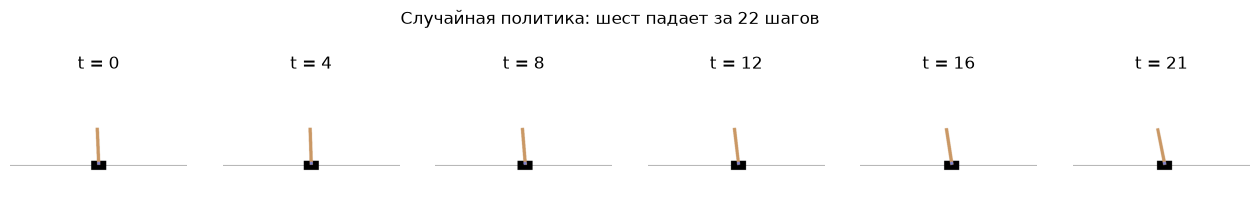

In [81]:
# Эпизод со случайной политикой: сохраним кадры.
env = gym.make("CartPole-v1", render_mode="rgb_array")
obs, _ = env.reset(seed=1)
frames = []
for t in range(60):
    frames.append(env.render())
    obs, r, terminated, truncated, _ = env.step(env.action_space.sample())
    if terminated or truncated:
        break
env.close()

idx = np.linspace(0, len(frames) - 1, 6).astype(int)
fig, axes = plt.subplots(1, 6, figsize=(16, 2.6))
for ax, i in zip(axes, idx):
    ax.imshow(frames[i])
    ax.set_title(f"t = {i}")
    ax.axis("off")
plt.suptitle(f"Случайная политика: шест падает за {len(frames)} шагов")
plt.show()

Случайная политика держит шест около 20 шагов. Правило выбора действия по состоянию называется **политикой**. Напишем политику руками: если шест падает вправо (угловая скорость положительная), толкаем тележку вправо, и наоборот.

In [82]:
def random_policy(obs):
    return np.random.randint(2)

def heuristic_policy(obs):
    x, x_dot, theta, theta_dot = obs
    return int(theta_dot > 0)   # толкаем в ту сторону, куда падает шест

def run_episodes(policy, n_episodes=50, seed=0):
    env = gym.make("CartPole-v1")
    returns = []
    for ep in range(n_episodes):
        obs, _ = env.reset(seed=seed + ep)
        total = 0
        while True:
            obs, r, terminated, truncated, _ = env.step(policy(obs))
            total += r
            if terminated or truncated:
                break
        returns.append(total)
    env.close()
    return np.array(returns)

np.random.seed(0)
for name, policy in [("случайная", random_policy), ("эвристика", heuristic_policy)]:
    G = run_episodes(policy)
    print(f"{name:10s}: средняя суммарная награда {G.mean():6.1f} ± {G.std():5.1f} (максимум 500)")

случайная : средняя суммарная награда   18.5 ±   7.3 (максимум 500)
эвристика : средняя суммарная награда  194.0 ±  39.6 (максимум 500)


Эвристика в 10 раз лучше случайной, но её придумал человек, зная физику задачи, и до максимума она не дотягивает. Для Atari, шахмат или гуманоида с 17 суставами такое правило руками не напишешь.

**Задача RL** — получить политику не хуже эвристики, **не зная** устройства среды, только из опыта взаимодействия. Первый такой алгоритм увидим сегодня в разделе 14, а на неделе 6 нейросеть будет стабильно держать 500 шагов.

**⏱ Если есть время**: посмотреть среду посложнее — LunarLander (нужен `box2d`).

In [ ]:
try:
    env = gym.make("LunarLander-v3", render_mode="rgb_array")
    obs, _ = env.reset(seed=0)
    frames = []
    for t in range(120):
        frames.append(env.render())
        obs, r, terminated, truncated, _ = env.step(env.action_space.sample())
        if terminated or truncated:
            break
    env.close()
    idx = np.linspace(0, len(frames) - 1, 4).astype(int)
    fig, axes = plt.subplots(1, 4, figsize=(16, 3.2))
    for ax, i in zip(axes, idx):
        ax.imshow(frames[i]); ax.set_title(f"t = {i}"); ax.axis("off")
    plt.suptitle("LunarLander, случайная политика: наблюдение из 8 чисел, 4 действия (двигатели)")
    plt.show()
except Exception as e:  # box2d не установлен или не собрался
    print("LunarLander недоступен:", type(e).__name__, "-", str(e)[:120])
    print("Гифку можно посмотреть в документации: https://gymnasium.farama.org/environments/box2d/lunar_lander/")

## 9. Живое демо: тележка на горке, хорошая и плохая политика

Среда одна, агент один, награда одна — меняется только **политика**. Посмотрим на двух «агентов», написанных руками:

* **«газ вправо»** — жадная к цели политика: цель справа, значит, всё время газуем вправо;
* **«раскачка»** — газуем туда, куда уже едем: `вправо`, если скорость положительна, и `влево`, если отрицательна.

Заодно сделаем маленькую утилиту `show_frames`, которая превращает кадры среды в анимацию прямо в ноутбуке (её же используем в разделе 14).

In [83]:
from matplotlib import animation
from IPython.display import HTML, display

def show_frames(frames, title="", interval=60, width=3.2):
    """Кадры среды -> анимация в ноутбуке (работает при запуске, в превью на GitHub не видна)."""
    h, w = frames[0].shape[:2]
    fig, ax = plt.subplots(figsize=(width, width * h / w))
    ax.axis("off"); ax.set_title(title, fontsize=10)
    im = ax.imshow(frames[0])
    plt.close(fig)
    anim = animation.FuncAnimation(fig, lambda i: (im.set_data(frames[i]),),
                                   frames=len(frames), interval=interval, blit=True)
    return HTML(anim.to_jshtml(default_mode="loop"))

«газ вправо»  : шагов 200, максимальная высота x = -0.30, доехал до флажка: НЕТ
«раскачка»    : шагов 101, максимальная высота x = +0.51, доехал до флажка: да


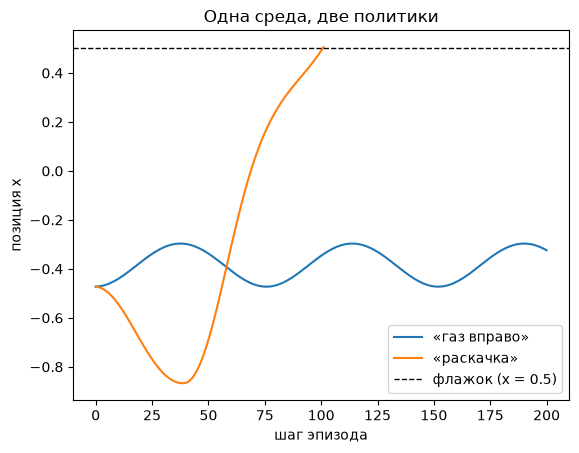

In [84]:
def run_mountain_car(policy, seed=0, max_steps=200, every=4):
    """Один эпизод MountainCar. Возвращает кадры (каждый every-й), позиции и флаг успеха."""
    env = gym.make("MountainCar-v0", render_mode="rgb_array", max_episode_steps=max_steps)
    obs, _ = env.reset(seed=seed)
    frames, xs, t, terminated = [], [obs[0]], 0, False
    while True:
        if t % every == 0:
            frames.append(env.render())
        obs, r, terminated, truncated, _ = env.step(policy(obs))
        xs.append(obs[0]); t += 1
        if terminated or truncated:
            break
    env.close()
    return frames, np.array(xs), terminated

gas_right   = lambda obs: 2                      # всегда газ вправо
swing       = lambda obs: 2 if obs[1] > 0 else 0  # газ в ту сторону, куда уже едем

for name, policy in [("«газ вправо»", gas_right), ("«раскачка»", swing)]:
    frames, xs, ok = run_mountain_car(policy)
    print(f"{name:14s}: шагов {len(xs)-1:3d}, максимальная высота x = {xs.max():+.2f}, "
          f"доехал до флажка: {'да' if ok else 'НЕТ'}")
    plt.plot(xs, label=name)

plt.axhline(0.5, color="k", ls="--", lw=1, label="флажок (x = 0.5)")
plt.xlabel("шаг эпизода"); plt.ylabel("позиция x"); plt.legend()
plt.title("Одна среда, две политики"); plt.show()

In [85]:
frames_bad, _, _ = run_mountain_car(gas_right)
frames_good, _, _ = run_mountain_car(swing)
display(show_frames(frames_bad, "Плохая политика: газ вправо, машинка не выезжает"))
display(show_frames(frames_good, "Хорошая политика: раскачка, машинка доезжает"))

Разница между «доехал» и «не доехал» — не в среде и не в награде, а только в политике. При этом «плохая» политика выглядит совершенно разумно: она всё время едет **к цели**. Проигрывает она потому, что жадничает — не готова временно ехать в противоположную сторону ради выигрыша потом. Ровно этому — терпеть сейчас ради суммарной награды — и учится RL-агент.

Обратите внимание и на другое: политику «раскачка» придумал человек, глядя на физику задачи. В разделе 14 такую же (и лучше) политику найдёт алгоритм, который про горки, тележки и энергию не знает ничего.

## 10. Марковское свойство и MDP

Чтобы про среду можно было что-то доказывать и программировать, нужна модель. Она называется **марковский процесс принятия решений** (MDP), и строится в два шага.

### 10.1 Марковское свойство и марковские цепи

**Случайный процесс** — последовательность случайных величин $S_0, S_1, S_2, \ldots$: состояние среды в моменты времени. Погода по дням, курс акции по минутам, клетка, в которой стоит агент.

В общем случае $S_{t+1}$ может зависеть от всей истории. **Марковское свойство** — упрощение, на котором держится весь RL:

$$
\mathbb{P}[S_{t+1} \mid S_t] = \mathbb{P}[S_{t+1} \mid S_0, S_1, \ldots, S_t].
$$

«Будущее зависит от прошлого только через настоящее.» Если состояние выбрано правильно, вся полезная история уже в нём — поэтому в CartPole в наблюдение включают скорости, а в Atari складывают 4 последних кадра: по одной картинке не видно, куда летит мяч.

**Марковская цепь** — состояния плюс матрица переходов $P$, где $P_{ss'} = \mathbb{P}[S_{t+1} = s' \mid S_t = s]$; строки суммируются в единицу. Пример — день студента:

![chain](../../assets/markov_chain.png)

In [115]:
rng = np.random.default_rng(0)
rng.choice(4, p=[0.5, 0.0, 0.5, 0.0])

0

In [86]:
states = ["Лекция", "Соцсети", "Сон", "Экзамен сдан"]
TERMINAL = states.index("Экзамен сдан")   # поглощающее состояние — выйти из него нельзя

P = np.array([
    [0.0, 0.5, 0.2, 0.3],   # из Лекции
    [0.3, 0.0, 0.7, 0.0],   # из Соцсетей
    [1.0, 0.0, 0.0, 0.0],   # из Сна
    [0.0, 0.0, 0.0, 1.0],   # Экзамен сдан: с вероятностью 1 остаёмся здесь навсегда
])
assert np.allclose(P.sum(axis=1), 1.0)   # из каждого состояния суммарно уходим с вероятностью 1

rng = np.random.default_rng(0)

def sample_chain(P, s0=0, max_steps=20):
    """Случайное блуждание по цепи: из s прыгаем в s' с вероятностью P[s, s']."""
    s, path = s0, [s0]
    for _ in range(max_steps):
        s = rng.choice(len(P), p=P[s])
        path.append(s)
        if s == TERMINAL:
            break
    return path

for _ in range(4):
    print(" -> ".join(states[s] for s in sample_chain(P)))

# Распределение по состояниям через n шагов.
# p — вектор-строка: p[i] = вероятность оказаться в состоянии i.
# Формула полной вероятности для одного шага цепи: p_new[j] = sum_i p[i] * P[i, j], т.е. p_new = p @ P.
# n шагов подряд — это n раз применённое умножение на P: p @ (P @ P @ ... @ P) = p @ P^n.
# np.linalg.matrix_power(P, n) как раз и вычисляет P^n.
p = np.array([1.0, 0.0, 0.0, 0.0])   # старт: наверняка в "Лекции"
for n in [1, 2, 5, 20]:
    p_n = p @ np.linalg.matrix_power(P, n)
    print(f"через {n:2d} шагов: " + ", ".join(f"{s} {x:.2f}" for s, x in zip(states, p_n)))

Лекция -> Сон -> Лекция -> Соцсети -> Лекция -> Экзамен сдан
Лекция -> Экзамен сдан
Лекция -> Сон -> Лекция -> Сон -> Лекция -> Экзамен сдан
Лекция -> Соцсети -> Сон -> Лекция -> Экзамен сдан
через  1 шагов: Лекция 0.00, Соцсети 0.50, Сон 0.20, Экзамен сдан 0.30
через  2 шагов: Лекция 0.35, Соцсети 0.00, Сон 0.35, Экзамен сдан 0.30
через  5 шагов: Лекция 0.24, Соцсети 0.06, Сон 0.15, Экзамен сдан 0.55
через 20 шагов: Лекция 0.02, Соцсети 0.01, Сон 0.02, Экзамен сдан 0.95


Матрица переходов отвечает на любой вопрос о будущем цепи: где мы окажемся через $n$ шагов ($p_0 P^n$), с какой вероятностью когда-нибудь сдадим экзамен. Историю хранить не нужно — в этом вся польза марковского свойства.

### 10.2 MDP: добавляем действия

Пока состояния менялись сами. Дадим агенту возможность **влиять** на переходы. **MDP** — кортеж $\langle \mathcal{S}, \mathcal{A}, P, R, \gamma \rangle$:

* $\mathcal{S}$ — состояния, $\mathcal{A}$ — действия;
* $P(s' \mid s, a)$ — вероятности переходов, теперь зависят от действия;
* $R(s, a)$ — ожидаемая награда за действие $a$ в состоянии $s$;
* $\gamma$ — коэффициент дисконтирования из раздела 5.

Траектория порождается так: агент в $S_0$ выбирает $A_0 \sim \pi(\cdot \mid S_0)$, получает награду $R_0$ и переходит в $S_1 \sim P(\cdot \mid S_0, A_0)$, и так далее:

$$
\tau = (S_0, A_0, S_1, A_1, \ldots), \qquad G(\tau) = \sum_{t \ge 0} \gamma^t R(S_t, A_t).
$$

Полезное наблюдение: **если политику зафиксировать, MDP превращается в обычную марковскую цепь** — действия «усредняются» с весами $\pi(a \mid s)$. Поэтому оценивать фиксированную политику проще, чем искать лучшую.

Пример MDP — GridWorld: состояние — клетка, действие — направление, переходы «скользкие» (вот она, случайность среды), награда за выход и за яму.

![gridworld](../../assets/mdp_gridworld.png)

Этого определения нам хватит на сегодня. На неделе 3 мы добавим к нему **ценность состояния** и **уравнение Беллмана** — из них вырастают почти все классические алгоритмы RL. Сегодняшний алгоритм обойдётся без них: он будет сравнивать целые траектории, а не отдельные шаги.

## 11. Награда — это формулировка задачи, и её легко испортить

Агент оптимизирует ровно то, что написано в награде, а не то, что вы имели в виду. Классический пример — [CoastRunners](https://openai.com/index/faulty-reward-functions/): агента-лодку обучали на игровые очки, и вместо прохождения трассы он нашёл лагуну, где можно бесконечно крутиться, собирать бонусы и врезаться в стены. Очков больше, чем у любого честного игрока. Это называется **reward hacking**; обзор с десятками примеров есть у [Lilian Weng](https://lilianweng.github.io/posts/2024-11-28-reward-hacking/).

> **Факт.** В экспериментах OpenAI с игрой в прятки агенты нашли ошибки в физическом движке: научились «сёрфить» на коробке и выкидывать предметы за пределы карты. Никто не закладывал такого поведения — оно просто приносило больше награды.

Практическое правило: награда должна описывать *что* нужно получить, а не *как* это делать. Если написать в награду «держи угол шеста маленьким», агент найдёт способ держать угол маленьким, необязательно тот, который вы ожидали.

## 12. Исследование и использование

Есть дилемма, которой нет ни в supervised, ни в unsupervised learning, и которая всплывёт у нас в каждом алгоритме курса.

* **Использование (exploitation)** — делать то, что по накопленному опыту кажется лучшим. Выгодно **сейчас**.
* **Исследование (exploration)** — пробовать то, про что мы мало знаем. Стоит награды сейчас, окупается **потом**.

Бытовые примеры:

* обед: пойти в проверенное кафе или попробовать новое?
* дорога домой: знакомый маршрут или тот, что предлагает навигатор?
* выбор курса, книги, вида спорта — то же самое.

Проблема в том, что оценка «лучшего» строится по нашему же опыту, а опыт мы собираем сами. Если после одного удачного обеда всегда ходить в одно кафе, мы никогда не узнаем, что через дорогу лучше: наша собственная политика закрыла нам доступ к этим данным. Посмотрим на это численно.

In [ ]:
rng = np.random.default_rng(0)
cafes = {"Столовая": 0.3, "Пекарня": 0.5, "Новое кафе": 0.7}   # вероятность удачного обеда (студенту неизвестна)
names, p_true = list(cafes), np.array(list(cafes.values()))
BEST = int(np.argmax(p_true))                                  # индекс кафе с самой высокой вероятностью

def student_life(days=100, n_explore=1):
    """n_explore дней подряд обходим все кафе по очереди (разведка), остальные дни ходим
    туда, где по итогам разведки доля удачных обедов оказалась выше (использование)."""
    successes = np.zeros(3)   # сколько раз обед в кафе a оказался удачным
    tries = np.zeros(3)       # сколько раз мы вообще заходили в кафе a
    happy_days = 0

    # Разведка: обходим все 3 кафе по очереди, набираем статистику.
    for cafe in range(3):
        for _ in range(n_explore):
            tasty = rng.binomial(1, p_true[cafe])   # 1 = обед понравился, 0 = нет
            successes[cafe] += tasty
            tries[cafe] += 1
            happy_days += tasty

    favourite = int(np.argmax(successes / tries))   # лучшее кафе по итогам разведки

    # Использование: все оставшиеся дни ходим только в любимое кафе.
    for _ in range(days - 3 * n_explore):
        happy_days += rng.binomial(1, p_true[favourite])

    return favourite, happy_days / days

for n_explore in [1, 3, 10]:
    lives = [student_life(n_explore=n_explore) for _ in range(2000)]
    picked_wrong = np.mean([favourite != BEST for favourite, _ in lives])
    avg_happiness = np.mean([happiness for _, happiness in lives])
    print(f"по {n_explore:2d} проб(ы) на кафе: выбрали не лучшее кафе в {picked_wrong:4.0%} случаев, "
          f"довольных обедов {avg_happiness:.0%} (максимум {p_true[BEST]:.0%})")

Чем меньше агент исследовал, тем чаще он навсегда «залипает» на неоптимальном варианте — и не потому, что плохо считает, а потому что перестал собирать данные. Отсюда простое правило, которым мы будем пользоваться весь курс: **политика во время обучения должна оставаться случайной**. Как именно дозировать случайность — тема семинара (там появятся стратегии $\varepsilon$-greedy и UCB1) и следующих недель. Нам сейчас важен сам факт: алгоритм, который мы напишем в разделе 14, работает именно потому, что его политика стохастическая.

## 13. Как оценить политику: метод Монте-Карло

Прежде чем улучшать политику, надо научиться её **измерять**. Качество политики $\pi$ — это ожидаемый return:

$$
J(\pi) = \mathbb{E}_{\pi}[G], \qquad G = \sum_{t \ge 0} \gamma^{t} r_{t+1}.
$$

Взять и посчитать это матожидание мы не можем: чтобы усреднить по всем возможным траекториям, нужно знать $P(s' \mid s, a)$ и $R(s, a)$ — модель среды. В разделе 10 мы записали MDP на бумаге, но в реальной задаче его таблицы никто не выдаёт. Зато агент умеет другое — **играть**. А по закону больших чисел среднее по сыгранным эпизодам сходится к матожиданию:

$$
J(\pi) \;=\; \mathbb{E}_{\pi}[G] \;\approx\; \frac{1}{K} \sum_{k=1}^{K} G(\tau_k), \qquad \tau_k \sim \pi .
$$

Это и есть **метод Монте-Карло**, он же **policy evaluation** в простейшем виде: хочешь узнать, хороша ли политика — сыграй ей много раз и усредни. Модель среды не нужна, нужна только возможность взаимодействовать; точность растёт как $1/\sqrt{K}$.

> Оценка политики по сыгранным эпизодам — базовый кирпич всего курса. На неделе 3 из него вырастут Monte-Carlo- и TD-обучение, а сегодня он понадобится как **шаг 1** первого алгоритма.

### Политика — это таблица

Чтобы сыграть эпизод, политику надо где-то хранить. Пока состояний и действий конечное число, удобнее всего матрицей:

$$
\pi[s, a] = \mathbb{P}[A_t = a \mid S_t = s], \qquad \sum_a \pi[s, a] = 1 \ \ \text{для каждого } s.
$$

Строка — состояние, столбец — действие, в клетке вероятность. Начинаем с **равномерной** политики $\pi[s, a] = 1/|\mathcal{A}|$: агент в каждом состоянии бросает кубик. Как мы выяснили в разделе 12, случайность здесь не недостаток, а необходимое условие — только так среди сотни эпизодов найдутся удачные, у которых есть чему учиться.

Возьмём Frozen Lake 4×4 без скольжения: 16 состояний, 4 действия, награда 1 за достижение цели и 0 во всех остальных случаях. Оценим равномерную политику по 500 эпизодам.

In [ ]:
env = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=False)
n_states, n_actions = env.observation_space.n, env.action_space.n

def run_session(env, policy, rng, max_steps=100):
    """Один эпизод: возвращает посещённые состояния, выбранные действия и суммарную награду."""
    obs, _ = env.reset(seed=int(rng.integers(1_000_000)))
    states, actions, total = [], [], 0.0
    for _ in range(max_steps):
        a = int(rng.choice(policy.shape[1], p=policy[obs]))   # действие ~ pi(.|s)
        states.append(obs); actions.append(a)
        obs, r, terminated, truncated, _ = env.step(a)
        total += r
        if terminated or truncated:
            break
    return states, actions, total

print("карта озера (S — старт, F — лёд, H — прорубь, G — цель):")
print("\n".join("  " + "".join(c.decode() for c in row) for row in env.unwrapped.desc))

rng = np.random.default_rng(0)
uniform_policy = np.ones((n_states, n_actions)) / n_actions

states_, actions_, G_ = run_session(env, uniform_policy, rng)
print("\nпример эпизода равномерной политики:")
print("  состояния:", states_)
print("  действия: ", actions_, "  (0=←, 1=↓, 2=→, 3=↑)")
print("  return:   ", G_)

# Оценка Монте-Карло: сыграть K раз и усреднить.
returns_uniform = np.array([run_session(env, uniform_policy, rng)[2] for _ in range(500)])
print(f"\n500 эпизодов: оценка J(pi) = {returns_uniform.mean():.3f}, "
      f"успешных эпизодов {int(returns_uniform.sum())}")

plt.hist(returns_uniform, bins=[-0.25, 0.25, 0.75, 1.25], rwidth=0.5)
plt.xticks([0, 1], ["провал (0)", "дошёл до цели (1)"])
plt.ylabel("число эпизодов"); plt.title("Оценка равномерной политики по 500 эпизодам")
plt.show()

Картина обескураживающая, но именно она и есть постановка задачи для следующего раздела. Обратите внимание на две вещи.

* **Оценка работает.** Не зная ни $P$, ни $R$, мы получили число, которым можно сравнивать политики между собой. Подставим вместо равномерной любую другую — и сразу увидим, лучше она или хуже.
* **Сигнал редкий.** Почти все эпизоды закончились нулём, вся полезная информация сидит в десятке удачных. Значит, улучшать политику придётся, вытаскивая её именно из этого десятка.

## 14. Первый алгоритм: метод Cross-Entropy

Оценивать политику мы научились. Осталось её **улучшать**.

Казалось бы, можно просто перебрать политики и выбрать лучшую. Посчитаем, сколько их: на Frozen Lake 4×4 состояний 16, действий 4, значит, детерминированных политик $4^{16} \approx 4.3 \cdot 10^9$. На поле 8×8 — уже $4^{64} \approx 3 \cdot 10^{38}$. Перебор безнадёжен, и это ещё простейшие среды.

Значит, политику нужно не перебирать, а **постепенно улучшать по собственному опыту**. Метод Cross-Entropy — самый простой способ это сделать, всего из трёх шагов.

### 14.1 Идея

Представьте, что вы учитесь готовить блюдо без рецепта. Вы готовите его 100 раз, каждый раз чуть по-разному. Потом отбираете 20 самых удачных попыток, смотрите, что в них общего («на этом шаге я обычно убавлял огонь»), и в следующей сотне попыток чаще делаете именно так. Через несколько кругов получается рецепт.

Ровно это и делает Cross-Entropy Method (CEM):

![cem](../../assets/cem_loop.png)

1. **Сыграть.** Провести $K$ эпизодов текущей (случайной) политикой и записать, что в них происходило и чем закончилось. Это в точности оценка Монте-Карло из раздела 13.
2. **Отобрать элиту.** Оставить лучшие эпизоды — те, у которых return выше порога.
3. **Подстроить политику.** Сделать так, чтобы действия из элитных эпизодов выбирались чаще.

И повторять. Алгоритм ничего не знает про устройство среды: ни $P(s' \mid s, a)$, ни $R(s, a)$ ему не нужны, он только играет и смотрит на результат — это **model-free** метод. И он не использует уравнение Беллмана: сравниваются целые траектории, а не отдельные шаги. Такие методы называют **эволюционными** или **методами прямого поиска в пространстве политик**.

### 14.2 Отбор элиты и обновление политики

Порог не задаём руками, а берём **квантиль** уровня $q$ от распределения returns. Но одного квантиля мало, и вот почему:

$$
\text{threshold} = \text{quantile}\big(\{G(\tau_k)\}_{k=1}^{K},\ q\big), \qquad
\text{элита} = \big\{\tau_k \ :\ G(\tau_k) \ge \text{threshold} \ \textbf{ и } \ G(\tau_k) > \min_j G(\tau_j)\big\}.
$$

Второе условие выглядит придиркой, но без него алгоритм не работает вовсе. Вспомните гистограмму из раздела 13: почти все эпизоды заканчиваются нулём — значит, и квантиль уровня $q = 0.7$ равен **нулю**. По одному лишь условию «не хуже порога» в элиту попали бы все 200 эпизодов, включая провальные, и политика выучила бы среднее поведение случайного агента, то есть не сдвинулась бы вообще.

Настоящий фильтр — это требование «строго лучше самого плохого». Оно оставляет ровно те несколько эпизодов из 200, которые чем-то отличились. А если не отличился никто, элита оказывается **пустой** и политика не меняется: алгоритм честно сообщает, что учиться не на чем. Мы увидим это дважды — в разделе 14.5 и на тележке в 14.6, где все эпизоды одинаковы по построению.

Почему вообще квантиль, а не фиксированное число: порог **сам подстраивается** под текущий уровень агента. Сегодня элита — это «хоть раз дошёл», через десять итераций — «дошёл за 6 шагов». Планка растёт вместе с политикой. Параметр $q$ — доля отбрасываемых эпизодов: при $q = 0.7$ учимся на лучших 30%. Слишком маленький $q$ — учимся у посредственности; слишком большой — элита из двух эпизодов, и обучение превращается в лотерею. Обычно берут $q$ от 0.5 до 0.9.

Новая политика — просто **частоты действий в элитных эпизодах**:

$$
\pi_{\text{new}}(a \mid s) = \frac{\#\{(s, a) \text{ встретилось в элите}\}}{\#\{s \text{ встретилось в элите}\}} .
$$

Если состояние в элите ни разу не встретилось, оставляем для него старую строку политики.

Разберём один шаг руками. Четыре эпизода в среде с двумя состояниями и двумя действиями, $q = 0.5$:

| эпизод | состояния | действия | return |
|---|---|---|---|
| 1 | 0, 1 | 0, 0 | 0 |
| 2 | 0, 1 | 1, 1 | **1** |
| 3 | 0, 0 | 0, 1 | 0 |
| 4 | 0, 1 | 1, 1 | **1** |

Порог — квантиль уровня 0.5 от $\{0, 1, 0, 1\}$, то есть 0.5; худший return равен 0. Оба условия выполняют эпизоды 2 и 4 — они и есть элита. Считаем, сколько раз элита делала действие $a$ в состоянии $s$:

| | $a = 0$ | $a = 1$ |
|---|---|---|
| $s = 0$ | 0 | 2 |
| $s = 1$ | 0 | 2 |

Делим каждую строку на её сумму — это и есть новая политика:

$$
\pi_{\text{old}} = \begin{pmatrix} 0.5 & 0.5 \\ 0.5 & 0.5 \end{pmatrix}
\quad \longrightarrow \quad
\pi_{\text{new}} = \begin{pmatrix} 0 & 1 \\ 0 & 1 \end{pmatrix}.
$$

Никакой магии: посчитали частоты. Заодно видно, чем это опасно. Действие 0 получило вероятность **ровно ноль** — и агент больше никогда его не выберет, а значит, никогда и не узнает, что бы из него вышло. Запомните эту матрицу, мы вернёмся к ней в 14.5.

### 14.3 Почему «кросс-энтропия»

Шаг 3 выглядит как «подсчёт палочек», но за ним стоит оптимизационная задача. Мы хотим политику, при которой элитные действия наиболее вероятны, то есть максимизируем **логарифм правдоподобия** элитных пар $(s, a)$:

$$
\max_{\pi} \sum_{(s, a) \in \text{элита}} \log \pi(a \mid s)
\quad \Longleftrightarrow \quad
\min_{\pi} \ \underbrace{-\sum_{s} \sum_{a} p_{\text{элита}}(a \mid s) \log \pi(a \mid s)}_{\text{кросс-энтропия } H(p_{\text{элита}},\ \pi)} .
$$

Мы минимизируем **кросс-энтропию** между эмпирическим распределением действий в элитных эпизодах и нашей политикой — отсюда название. Для табличной политики эта задача решается в явном виде, и решение — те самые частоты, которые мы посчитали.

Отсюда главная мысль раздела и мостик к разделу 3:

> На каждой итерации CEM превращает задачу RL в обычную задачу **обучения с учителем**: «объекты» — состояния из элитных эпизодов, «правильные ответы» — действия, которые агент в них сделал, функция потерь — кросс-энтропия. Разница с supervised learning только в том, что разметку никто не давал: агент **сгенерировал её себе сам**, отобрав свои же лучшие попытки.

Это же объясняет, как метод масштабируется. Когда состояний слишком много, чтобы держать таблицу (кадры Atari, координаты робота), таблицу заменяют нейросетью $\pi_\theta(a \mid s)$, а шаг 3 — несколькими шагами градиентного спуска по той же самой кросс-энтропии (`nn.CrossEntropyLoss` в PyTorch, элитные состояния как батч, элитные действия как метки классов). Получается deep Cross-Entropy Method — им займёмся на неделе 5.

### 14.4 Алгоритм целиком

```text
policy = равномерная таблица (n_states × n_actions)
повторять n_iter раз:
    sessions  = [сыграть эпизод текущей policy] × n_sessions      # шаг 1
    threshold = квантиль уровня q от returns этих эпизодов        # шаг 2
    elite     = эпизоды с return >= threshold и > худшего return
    counts[s, a] = сколько раз элита делала a в s                 # шаг 3
    policy[s] = counts[s] / sum(counts[s])   для встреченных s
```

In [ ]:
def cross_entropy_method(env, n_iter=10, n_sessions=200, q=0.7, seed=0, max_steps=100,
                         laplace=0.0, mix=1.0):   # «лекарства» из 14.5, по умолчанию выключены
    rng = np.random.default_rng(seed)
    n_states, n_actions = env.observation_space.n, env.action_space.n
    policy = np.ones((n_states, n_actions)) / n_actions
    history, snapshots = [], [policy.copy()]     # средний return и политика на каждой итерации

    for _ in range(n_iter):
        # Шаг 1: сыграть n_sessions эпизодов текущей политикой (Монте-Карло, раздел 13).
        sessions = [run_session(env, policy, rng, max_steps) for _ in range(n_sessions)]
        returns = np.array([G for _, _, G in sessions])

        # Шаг 2: отобрать элиту — эпизоды не хуже порога И строго лучше самых плохих.
        # Второе условие кажется придиркой, но без него алгоритм не работает вовсе:
        # почти все эпизоды дают return 0, поэтому и квантиль равен нулю, и по одному
        # лишь «G >= threshold» в элиту попали бы ВСЕ эпизоды, включая провальные (см. 14.2).
        threshold = np.quantile(returns, q)
        elite = [(states, actions) for states, actions, G in sessions
                 if G >= threshold and G > returns.min()]

        # Шаг 3: новая политика — частоты действий элиты. Строки состояний, куда элита
        # не заходила, остаются прежними.
        counts = np.full((n_states, n_actions), laplace)
        for states, actions in elite:
            for s, a in zip(states, actions):
                counts[s, a] += 1
        new_policy = policy.copy()
        seen = counts.sum(axis=1) > 0
        new_policy[seen] = counts[seen] / counts[seen].sum(axis=1, keepdims=True)
        policy = mix * new_policy + (1 - mix) * policy

        history.append(returns.mean()); snapshots.append(policy.copy())
    return policy, history, snapshots

In [ ]:
policy_lake, history, _ = cross_entropy_method(env, n_iter=10, n_sessions=200, q=0.7)

plt.plot(history, marker="o")
plt.xlabel("итерация"); plt.ylabel("средний return (здесь — доля успешных эпизодов)")
plt.title("Cross-Entropy на Frozen Lake 4×4"); plt.show()

# Стрелку рисуем только там, где политика явно предпочла одно действие. Там, где строка
# осталась почти равномерной, никакого «выученного действия» нет и argmax нарисовал бы
# случайную стрелку — ставим «·».
probs = np.sort(policy_lake, axis=1)
decided = probs[:, -1] - probs[:, -2] > 0.1

arrows = "←↓→↑"
desc = ["".join(c.decode() for c in row) for row in env.unwrapped.desc]
print("выученная политика («·» — политика в клетке осталась равномерной):")
for r in range(4):
    print("  " + " ".join(desc[r][c] if desc[r][c] in "HG"
                          else (arrows[int(np.argmax(policy_lake[r * 4 + c]))]
                                if decided[r * 4 + c] else "·")
                          for c in range(4)))

rng_eval = np.random.default_rng(0)
success = np.mean([run_session(env, policy_lake, rng_eval)[2] for _ in range(500)])
print(f"\nдоля успешных эпизодов: {success:.0%} (действия сэмплируются из π(·|s))")

untouched = int((np.abs(policy_lake - 1 / n_actions).max(axis=1) < 1e-9).sum())
print(f"строк политики, оставшихся равномерными: {untouched} из {n_states} — "
      "в эти клетки элита ни разу не заходила")

Посмотрите на график: обучение заняло **ровно одну** итерацию. Первая же удачная траектория попала в элиту, алгоритм её скопировал, дальше все 200 эпизодов стали успешными — а тогда худший return сравнялся с лучшим, элита опустела, и политика застыла. Это и удобно, и опасно.

Ещё одно наблюдение к разделу 12: стрелки показывают лишь **самое вероятное** действие, а пользоваться такой политикой нужно именно случайно. Точками отмечены клетки, где вероятности так и остались равными: агент туда почти не заходил, никакого «выученного действия» там нет. «Жадный» выбор действия в таких клетках может зациклить агента между двумя клетками — с этим эффектом вы столкнётесь в домашнем задании.

### 14.5 Что может пойти не так

Алгоритм из трёх шагов, конечно, хрупкий. Три типичные болезни.

**1. Мало эпизодов на итерацию.** Если среди сыгранных эпизодов ни один не дошёл до цели, все returns одинаковы, элита пуста — политика не двигается, и так может продолжаться сколь угодно долго. Чем больше среда, тем реже случайный успех и тем больше эпизодов нужно на каждую итерацию.

**2. Схлопывание политики.** Частоты — очень жёсткое обновление: действие, не попавшее в элиту, получает вероятность ровно 0 и больше **никогда** не будет опробовано — агент сам закрыл себе доступ к этим данным (ровно то, о чём раздел 12, и ровно та матрица $\pi_{\text{new}}$ из 14.2). Одна удачная траектория может «выключить» все альтернативы, и алгоритм застрянет на первом найденном решении, даже если рядом есть куда лучше.

**3. Случайность среды.** На скользком льду эпизод может закончиться успехом просто потому, что повезло с направлением скольжения. В элиту тогда попадают везучие, а не умные, и политика учится на шуме.

Лекарство от болезни 2 (и отчасти от 3) — не доверять одной итерации полностью:

* **сглаживание по Лапласу**: к счётчикам добавляем $\lambda$, так что $\pi(a \mid s) = \dfrac{n(s,a) + \lambda}{n(s) + \lambda\,|\mathcal{A}|}$ — ни одно действие не обнуляется, агент продолжает изредка пробовать всё;
* **смешивание со старой политикой**: $\pi \leftarrow \alpha\,\pi_{\text{new}} + (1 - \alpha)\,\pi_{\text{old}}$ — политика меняется плавно, как learning rate в градиентном спуске.

Посмотрим на болезни 1 и 2 своими глазами; болезнь 3 останется вам на дом.

In [ ]:
# Болезнь 1: мало эпизодов на итерацию. По 5 эпизодов вместо 200, шесть запусков.
finals = [cross_entropy_method(env, n_iter=10, n_sessions=5, seed=s)[1][-1] for s in range(6)]
print("5 эпизодов на итерацию, доля успехов на последней итерации:",
      ", ".join(f"{f:.0%}" for f in finals))

p = returns_uniform.mean()            # доля успехов равномерной политики из раздела 13
print(f"вероятность не найти НИ ОДНОГО успешного эпизода: "
      f"среди 5 — {(1 - p) ** 5:.0%}, среди 200 — {(1 - p) ** 200:.0%}")

# Болезнь 2: схлопывание. Сколько вероятностей обнулилось всего за три итерации?
for label, cure in [("без сглаживания", {}),
                    ("Лаплас λ=1, смесь α=0.5", dict(laplace=1.0, mix=0.5))]:
    policy_3, _, _ = cross_entropy_method(env, n_iter=3, n_sessions=200, **cure)
    print(f"{label:24s}: действий с нулевой вероятностью {(policy_3 == 0).mean():.0%}")

In [ ]:
from matplotlib import animation
from IPython.display import HTML

# Лекарство в действии: те же 200 эпизодов на итерацию, но политика меняется плавно.
policy_smooth, history_smooth, snapshots = cross_entropy_method(
    env, n_iter=12, n_sessions=200, q=0.7, laplace=0.5, mix=0.5)

plt.plot(history, marker="o", label="без сглаживания")
plt.plot(history_smooth, marker=".", label="Лаплас λ=0.5, смесь α=0.5")
plt.xlabel("итерация"); plt.ylabel("средний return")
plt.title("Сглаживание превращает обрыв в кривую обучения"); plt.legend(); plt.show()

def animate_policy(snapshots, history, desc, interval=400, width=4.2):
    """Каждый кадр — одна итерация: стрелка = самое вероятное действие, насыщенность = уверенность."""
    nrow, ncol = len(desc), len(desc[0])
    fig, ax = plt.subplots(figsize=(width, width * 1.05))
    plt.close(fig)

    def draw(k):
        ax.clear(); ax.set_xticks([]); ax.set_yticks([])
        ax.set_xlim(0, ncol); ax.set_ylim(nrow, 0)
        for r in range(nrow):
            for c in range(ncol):
                cell = desc[r][c]
                if cell in "HG":
                    ax.add_patch(plt.Rectangle((c, r), 1, 1,
                                               color="#a8c8ec" if cell == "H" else "#a9dfa9"))
                    ax.text(c + 0.5, r + 0.5, cell, ha="center", va="center", fontsize=11)
                    continue
                p = snapshots[k][r * ncol + c]
                a = int(np.argmax(p))
                ax.text(c + 0.5, r + 0.5, arrows[a], ha="center", va="center",
                        fontsize=18, alpha=0.15 + 0.85 * float(p[a]))
        for i in range(max(nrow, ncol) + 1):
            ax.axhline(i, color="k", lw=0.4); ax.axvline(i, color="k", lw=0.4)
        rate = history[k - 1] if k else 0.0
        ax.set_title(f"итерация {k},  доля успехов {rate:.0%}", fontsize=10)

    anim = animation.FuncAnimation(fig, draw, frames=len(snapshots), interval=interval)
    return HTML(anim.to_jshtml(default_mode="loop"))

animate_policy(snapshots, history_smooth, desc)

Болезнь 1 видно сразу: с пятью эпизодами на итерацию часть запусков так и остаётся на нуле — успешных траекторий просто не нашлось, элита пуста, учиться не на чем. Арифметика объясняет, почему: при доле успеха около 2% шанс не встретить ни одного удачного эпизода среди пяти — девять из десяти, а среди двухсот — всего 2%. Это не «неудачные гиперпараметры», а свойство метода: он живёт за счёт случайных успехов, и чем больше среда, тем реже они случаются. На поле 8×8 случайная политика доходит до цели примерно в одном эпизоде из шестисот (0.17%) — прикиньте сами, сколько эпизодов на итерацию там понадобится.

Схлопывание видно прямо в числах: без сглаживания уже через три итерации заметная часть всех вероятностей равна нулю — эти действия агент больше никогда не выберет. Со сглаживанием по Лапласу нулей нет вовсе.

А главное — посмотрите на анимацию. Без сглаживания политика прыгала в готовый ответ за одну итерацию; со сглаживанием видно, как из полного хаоса постепенно проступает маршрут в обход прорубей, и как растёт уверенность агента в каждой клетке. Это и есть тот самый цикл «сыграть — отобрать — подстроить», прокрученный десяток раз.

**📖 Дома**: запустите тот же алгоритм на скользком льду (`is_slippery=True`) и посмотрите, как ведут себя кривые. Это болезнь 3, которую мы сегодня не запускали. Спойлер: результат скачет от запуска к запуску и заметно не дотягивает до оптимальных 74% — в элиту попадают везучие эпизоды, а не умные.

### 14.6 Второй пример: тележка на горке

<small>Обучение в этом разделе занимает около полуминуты — на лекции ячейки лучше прогнать заранее.</small>

Frozen Lake — клеточный мир, где состояния уже пронумерованы. Что делать с непрерывным состоянием, как в Mountain Car (позиция и скорость)? Простейший ответ — **дискретизировать**: разбить каждую координату на несколько интервалов и считать номер клетки сетки номером состояния. Возьмём сетку $12 \times 12$, то есть 144 состояния и 3 действия.

Но сначала — честная демонстрация первой болезни во всей красе.

In [ ]:
NBINS = 12
LOW, HIGH = np.array([-1.2, -0.07]), np.array([0.6, 0.07])
GOAL_X = 0.5                        # на этой высоте стоит флажок

def encode(obs):
    """Непрерывное состояние (x, v) -> номер клетки сетки 12×12."""
    i = np.clip(((obs - LOW) / (HIGH - LOW) * NBINS).astype(int), 0, NBINS - 1)
    return int(i[0] * NBINS + i[1])

def mc_session(env, policy, rng, max_steps=200):
    """Как run_session, но состояние дискретизируется и запоминается максимальная высота."""
    obs, _ = env.reset(seed=int(rng.integers(1_000_000)))
    states, actions, total, best_x = [], [], 0.0, obs[0]
    for _ in range(max_steps):
        s = encode(obs)
        a = int(rng.choice(3, p=policy[s]))
        states.append(s); actions.append(a)
        obs, r, terminated, truncated, _ = env.step(a)
        total += r
        best_x = max(best_x, obs[0])
        if terminated or truncated:
            break
    return states, actions, total, best_x

mc_env = gym.make("MountainCar-v0", max_episode_steps=200)
rng = np.random.default_rng(0)
uniform_mc = np.ones((NBINS * NBINS, 3)) / 3
returns_mc = np.array([mc_session(mc_env, uniform_mc, rng)[2] for _ in range(200)])

print(f"200 эпизодов равномерной политики: return от {returns_mc.min():.0f} до "
      f"{returns_mc.max():.0f}, разных значений всего {len(np.unique(returns_mc))}")
print(f"порог элиты (квантиль 0.7): {np.quantile(returns_mc, 0.7):.0f}")
print("=> все эпизоды одинаково плохи, элита пуста, CEM в таком виде не сдвинется с места.")

Это и есть **проблема разрежённой награды**: сигнал «−1 за шаг» одинаков для всех, пока ни один эпизод случайно не доехал до флажка, а случайной политикой это не происходит практически никогда. Обратите внимание: сработал ровно тот механизм, о котором говорилось в 14.2 — худший return равен лучшему, элита пуста, политика не двигается.

Что можно сделать? Подсказать агенту промежуточную цель: отбирать элиту не по награде, а по **максимальной высоте**, которой достигла машинка. Это ровно тот приём, о котором предупреждал раздел 11: мы вмешиваемся в постановку задачи, и делать это надо осторожно (агент будет оптимизировать именно то, что мы написали). Зато сигнал становится плотным: «эта попытка заехала выше, чем та» — и алгоритм оживает.

In [ ]:
def cem_mountain_car(n_iter=45, n_sessions=150, q=0.7, laplace=1.0, mix=0.6,
                     seed=0, max_steps=200):
    """Тот же CEM, но элита отбирается по максимальной высоте, а не по награде."""
    rng = np.random.default_rng(seed)
    env = gym.make("MountainCar-v0", max_episode_steps=max_steps)
    policy = np.ones((NBINS * NBINS, 3)) / 3
    height, success, visits = [], [], np.zeros(NBINS * NBINS)

    for _ in range(n_iter):
        sessions = [mc_session(env, policy, rng, max_steps) for _ in range(n_sessions)]
        best_x = np.array([x for _, _, _, x in sessions])
        # Высота — величина непрерывная, одинаковых эпизодов практически не бывает,
        # поэтому здесь, в отличие от озера, хватает одного порога-квантиля.
        threshold = np.quantile(best_x, q)
        elite = [(states, actions) for states, actions, _, x in sessions if x >= threshold]

        counts = np.full((NBINS * NBINS, 3), laplace)   # laplace > 0 обязателен: без него
        for states, actions in elite:                   # непосещённые клетки дадут 0/0
            for s, a in zip(states, actions):
                counts[s, a] += 1
                visits[s] += 1
        policy = mix * (counts / counts.sum(axis=1, keepdims=True)) + (1 - mix) * policy

        height.append(best_x.mean())
        success.append(float((best_x >= GOAL_X).mean()))   # доехал = поднялся до флажка
    env.close()
    return policy, height, success, visits


policy_mc, height, success_mc, visits = cem_mountain_car()      # около полуминуты

fig, ax1 = plt.subplots(figsize=(7, 4))
ax1.plot(height, color="C0", marker=".")
ax1.axhline(GOAL_X, color="k", ls="--", lw=1)
ax1.set_xlabel("итерация"); ax1.set_ylabel("средняя максимальная высота x", color="C0")
ax2 = ax1.twinx()
ax2.plot(success_mc, color="C2", marker=".")
ax2.set_ylabel("доля эпизодов, доехавших до флажка", color="C2")
plt.title("Cross-Entropy учит машинку раскачиваться"); plt.show()
print(f"доля успешных эпизодов на последней итерации: {success_mc[-1]:.0%}")

In [ ]:
# Как выглядит выученная политика.
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

# В клетках, куда элита ни разу не попадала, политика осталась равномерной:
# argmax там ничего не значит и закрасил бы полкартинки ложным «газ влево». Прячем их.
grid = np.argmax(policy_mc.reshape(NBINS, NBINS, 3), axis=2).astype(float)
grid[visits.reshape(NBINS, NBINS) == 0] = np.nan

colors = ["#3b6fb0", "#f0c419", "#c0392b"]      # 0 = газ влево, 1 = ничего, 2 = газ вправо
cmap = ListedColormap(colors); cmap.set_bad("#ebebeb")

plt.figure(figsize=(5.2, 4.2))
plt.imshow(grid.T, origin="lower", cmap=cmap, vmin=-0.5, vmax=2.5,
           extent=[LOW[0], HIGH[0], LOW[1], HIGH[1]], aspect="auto")
plt.axhline(0, color="k", lw=0.8, ls="--")
plt.xlabel("позиция x"); plt.ylabel("скорость v")
plt.title("Выученная политика")
plt.legend(handles=[Patch(facecolor=c, label=l) for c, l in
                    zip(colors + ["#ebebeb"], ["газ влево", "ничего", "газ вправо", "агент здесь не был"])],
           loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=2, frameon=False)
plt.show()
print(f"клеток, где элита ни разу не была: {int((visits == 0).sum())} из {NBINS * NBINS}")

In [ ]:
# И как она едет.
rng = np.random.default_rng(0)
mc_render = gym.make("MountainCar-v0", render_mode="rgb_array", max_episode_steps=200)
obs, _ = mc_render.reset(seed=3)
frames, t = [], 0
while True:
    if t % 4 == 0:
        frames.append(mc_render.render())
    a = int(rng.choice(3, p=policy_mc[encode(obs)]))
    obs, r, terminated, truncated, _ = mc_render.step(a)
    t += 1
    if terminated or truncated:
        break
mc_render.close()
show_frames(frames, f"Политика, выученная CEM: {'доехал' if terminated else 'не доехал'} за {t} шагов")

Обратите внимание на картинку политики: агент сам, без единой подсказки о физике, пришёл к правилу «газ в ту сторону, куда уже едешь» — то есть переоткрыл эвристику из раздела 9, которую там придумал человек. Красная область (газ вправо) — это положительные скорости, синяя (газ влево) — отрицательные. Серые клетки — сочетания позиции и скорости, в которых элита ни разу не оказывалась: там политика так и осталась равномерной, и читать по ней «выученное действие» нельзя. Это обычная картина для табличных методов: агент знает только то, что успел посетить.

### 14.7 Итог раздела

Что мы получили: рабочий алгоритм RL из трёх шагов — сыграть, отобрать лучшее, повторить то, что в нём делали. Никаких нейросетей, никакого знания среды, два десятка строк кода.

Где у него границы:

* нужны **дискретные** состояния и действия (или дискретизация, как в Mountain Car, — а она плохо масштабируется: сетка $12^2$ ещё ничего, а $12^{17}$ для гуманоида уже невозможна);
* нужно **много эпизодов**: политика оценивается только целыми траекториями, информация об отдельных шагах не используется;
* плохо работает при **разрежённой награде** и в сильно **случайных** средах;
* учитывается только итог эпизода, поэтому длинный горизонт даётся тяжело.

Куда двигаться дальше:

* **неделя 5** — та же схема, но политика-таблица заменяется нейросетью, а шаг 3 — градиентным спуском по кросс-энтропии: тот же алгоритм решает CartPole и LunarLander;
* **неделя 3** — там продолжится линия из раздела 13: методы Монте-Карло и TD, которые используют структуру MDP и уравнение Беллмана и извлекают информацию из **каждого шага**, а не из целого эпизода, и потому куда экономнее по данным.

## 15. Карта курса

![course](../../assets/course_map.png)

Первые четыре недели — **основы**: постановка задачи, построение сред, табличные value-based и policy-based методы. Дальше те же идеи переносим на нейросети (**deep RL**: DQN, policy gradient, actor-critic), потом продвинутые методы (PPO, TD3, model-based), и расширения: иерархический и многоагентный RL, трансформеры.

![taxonomy](../../assets/rl_taxonomy.png)

Всё, что в этой таблице, мы **реализуем сами** с нуля: от Cross-Entropy до PPO и TD3. RL-алгоритмы печально известны тем, что «почти работающая» реализация не работает вовсе, и понять, где ошибка, можно только зная каждую строчку.

## Итоги лекции

1. **Reinforcement Learning зарождался в психологии.** «Подкрепление» и закон эффекта описывают тот же механизм, который мы теперь программируем; математику к нему добавила теория управления.
2. **Reinforcement Learning можно выделить в отдельную группу алгоритмов машинного обучения.** Нет правильных ответов, награда отложена, данные порождает сам агент, нужно исследовать. Ни одной из этих черт нет в supervised и unsupervised learning.
3. **Reinforcement Learning широко применяется в самых разных областях: от игр до управления охлаждением дата-центров и от торговли на бирже до роевого поведения дронов.** Рецепт один: среда + числовая цель.

Словарь, который нужно унести с собой: **агент, среда, состояние, действие, награда, политика, эпизод, терминальное состояние, return и дисконтирование, марковское свойство, MDP, исследование и использование, оценка политики методом Монте-Карло, метод Cross-Entropy**.

## Литература

* R. Sutton, A. Barto. *Reinforcement Learning: An Introduction*, 2nd ed. — [бесплатный PDF](http://incompleteideas.net/book/the-book-2nd.html). Глава 1 — сегодняшняя лекция, главы 3–4 понадобятся на неделе 3.
* D. Silver. [UCL Course on RL](https://www.davidsilver.uk/teaching/), лекция 1: введение (лекция 2 про MDP — к неделе 3).
* А. Плаксин. [Курс imm-rl-lab](https://github.com/imm-rl-lab/reinforcement_learning_course), лекция 1: введение и метод Cross-Entropy.
* [OpenAI Spinning Up](https://spinningup.openai.com/) — короткое введение + чистые реализации.
* [Gymnasium](https://gymnasium.farama.org/) — документация по средам и интерфейсу.

## На семинаре и дома

* Семинар (`../seminar/seminar.ipynb`): интерфейс Gymnasium на Frozen Lake, политика-таблица, среда бандита и агенты ε-greedy / UCB1, реализация Cross-Entropy.
* Мини-семинар по PyTorch (`../seminar/pytorch_intro.ipynb`) для тех, кто с ним не работал.
* ДЗ (`../homework/homework.ipynb`): бандиты, теория (return, марковская цепь, MDP на бумаге), Cross-Entropy на Frozen Lake 8×8.